In [41]:
import cv2
import gymnasium as gym
import ale_py
from gymnasium.wrappers import RecordVideo, AtariPreprocessing

import os

import numpy as np

import random

from collections import deque

import torch
import torch.nn as nn

import matplotlib.pyplot as plt

In [42]:
dqn_dir = "../data/dqn"
train_video_dir = f"{dqn_dir}/training"

In [43]:
class ResizeRender(gym.Wrapper):
    def render(self):
        frame = self.env.render()

        return cv2.resize(
            frame,
            (800, 1050),
            interpolation=cv2.INTER_NEAREST
        )

In [44]:
train_episodes = 1000
training_period = train_episodes // 10
frameskips = 3

gym.register_envs(ale_py)
env = gym.make("ALE/Pacman-v5", frameskip=1, render_mode="rgb_array")
env = AtariPreprocessing(env, scale_obs=True, frame_skip=frameskips)
env = ResizeRender(env)
env = RecordVideo(env, video_folder=train_video_dir, name_prefix="training",
    episode_trigger=lambda x: x % training_period == 0)

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
device

'cuda'

In [46]:
obs, info = env.reset()
obs.shape, info

((84, 84), {'lives': 4, 'episode_frame_number': 41, 'frame_number': 57})

In [47]:
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

In [48]:
obs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(84, 84), dtype=float32)

In [49]:
reward, info

(0.0, {'lives': 4, 'episode_frame_number': 44, 'frame_number': 60})

In [50]:
action_size = env.action_space.n
action_size

np.int64(5)

In [51]:
class PacmanAgent(nn.Module):
    def __init__(self, n_hid, n_out):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(frameskips, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),         
               
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, n_hid),
            nn.ReLU(),  
            nn.Linear(n_hid, n_out)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.head(x)
    
def choose_action(model, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(0, action_size)
       
    state = torch.tensor(state, dtype=torch.float32, device=device)
    state = state.unsqueeze(0)
    with torch.no_grad():
        out = model(state)
    return int(torch.argmax(out).item())
    
    
def sample_batch(buffer, batch_size):
    batch = random.sample(buffer, batch_size)

    state, action, reward, next_state, done = map(
        np.array, zip(*batch)
    )

    return (
        torch.tensor(state, dtype=torch.float32, device=device),
        torch.tensor(action, dtype=torch.int64, device=device),
        torch.tensor(reward, dtype=torch.float32, device=device),
        torch.tensor(next_state, dtype=torch.float32, device=device),
        torch.tensor(done, dtype=torch.float32, device=device)
    )

def update_target(target, model):
    target.load_state_dict(model.state_dict())

def train_step(model, target, optimizer, batch, gamma=0.99):
    state, action, reward, next_state, done = batch

    with torch.no_grad():
        next_out = target(next_state).max(dim=1)[0]
        target_out = reward + (1 - done) * gamma * next_out

    out = model(state).gather(1, action.unsqueeze(1)).squeeze(1)

    loss = nn.SmoothL1Loss()(out, target_out) # or MSE

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def linear_schedule(start_e: float, end_e: float, duration: int, t: int):
    slope = (end_e - start_e) / duration
    return max(slope * t + start_e, end_e)

def train(env, model, target, optimizer,
          episodes=2000,
          start_eps = 0.8,
          end_eps = 0.05,
          batch_size=64, 
          gamma=0.99,
          target_update_freq=1000):
    
    buffer = deque(maxlen=100_000)
    global_step = 0
    reward_history = []

    for episode in range(episodes):
        stack = deque(maxlen=frameskips)
        
        obs, _ = env.reset()
        done = False
        total_reward = 0

        for _ in range(frameskips):
            stack.append(obs)

        epsilon = linear_schedule(start_eps, end_eps, episodes, episode)
            
        state = np.stack(stack, axis=0)

        while not done:
            action = choose_action(model, state, epsilon)
            next_obs, reward, terminated, truncated, info  = env.step(action)
            
            stack.append(next_obs)
            next_state = np.stack(stack, axis=0)
            
            done = terminated or truncated or info["lives"] == 3
                        
            buffer.append((state.copy(), action, reward, next_state.copy(), done))

            obs = next_obs
            state = next_state
            total_reward += reward
            global_step += 1

            if len(buffer) > batch_size:
                batch = sample_batch(buffer, batch_size)
                train_step(model, target, optimizer, batch, gamma)

            if global_step % target_update_freq == 0:
                update_target(target, model)

    
        reward_history.append(total_reward)

        print(f"\rEpisode: {episode + 1} | reward: {total_reward} | eps: {epsilon} | global_steps: {global_step}", end=" ")

    return reward_history

In [52]:
torch.manual_seed(42)

agent = PacmanAgent(512, action_size).to(device)
agent.load_state_dict(torch.load(f"{dqn_dir}/v2/agent.pth"))


target = PacmanAgent(512, action_size).to(device)
target.load_state_dict(torch.load(f"{dqn_dir}/v2/target.pth"))

optimizer = torch.optim.NAdam(agent.parameters(), lr=1e-3)
optimizer.load_state_dict(torch.load(f"{dqn_dir}/v2/optimizer.pth"))

rewards_history = train(
    env=env,
    model=agent,
    target=target,
    optimizer=optimizer,
    episodes=train_episodes,
    start_eps=0.3,
    end_eps=0.03,
    batch_size=64,
    gamma=0.99,
    target_update_freq=2000
)

Episode: 1000 | reward: 4.0 | eps: 0.030269999999999964 | global_steps: 183550 

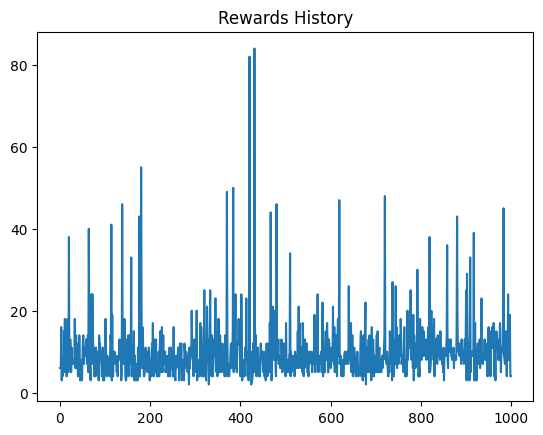

In [53]:
rewards = np.array(rewards_history)

plt.plot(rewards)
plt.title("Rewards History")
plt.show()

In [54]:
torch.save(agent.state_dict(), "agent.pth")
torch.save(target.state_dict(), "target.pth")
torch.save(optimizer.state_dict(), "optimizer.pth")